<a href="https://colab.research.google.com/github/AlishbaMalik687-svg/AI-ML-internship_task-4/blob/master/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

Loading Dataset

In [2]:
df=pd.read_csv('/content/House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Pre-processing

In [3]:
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)  #missing values fill honi just in numeric colums

Split 'Target' and 'Features'

In [4]:
M=df.drop(columns=['Price'],axis=1)   #price column target kia hai
n=df['Price']

Split 'Test' and 'Train'

In [5]:
M_train, M_test, n_train, n_test = train_test_split(M, n, test_size=0.2, random_state=42)   #80% training and 20% testing

print('Size of M Train:', M_train.shape)
print('Size of M Test:', M_test.shape)
print('Size of n Train:', n_train.shape)
print('Size of n Test:', n_test.shape)

Size of M Train: (1600, 9)
Size of M Test: (400, 9)
Size of n Train: (1600,)
Size of n Test: (400,)


Standard Scaler

In [6]:
M_train = M_train.select_dtypes(include=['int64', 'float64'])   #dataset me se just numeric values pe kam hoga
M_test  = M_test.select_dtypes(include=['int64', 'float64'])

sc=StandardScaler()
M_train=sc.fit_transform(M_train)
M_test=sc.transform(M_test)

Model:Gradient Boosting

In [7]:
gb = GradientBoostingRegressor()
gb.fit(M_train, n_train)    #training data se model learn hoga
n_pred=gb.predict(M_test)  #test model pe prediction krega

MAE:Mean Absolute Error

In [8]:
mae = mean_absolute_error(n_test, n_pred)   # ye hmy btayega k predicted value actual se kitni dor hai
print("MAE:", mae)


MAE: 245875.3354664228


RMSE:Root Mean Square Error

In [9]:
rmse = np.sqrt(mean_squared_error(n_test, n_pred))      #model ki prediction average kitni error kar rahi hai
print("RMSE:", rmse)


RMSE: 284355.43672695634


●	Visualize predicted prices compared to actual prices.

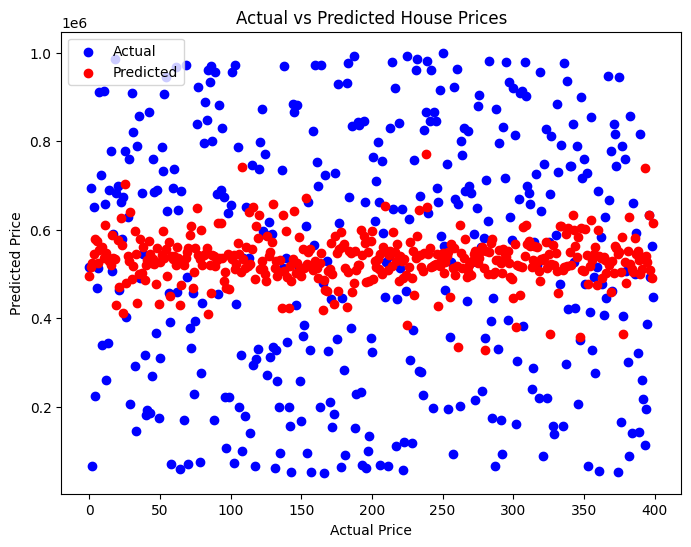

In [11]:
plt.figure(figsize=(8,6))    ##graph size

plt.scatter(range(len(n_test)), n_test, color='blue', label="Actual")  #n_test-> actual value hai
plt.scatter(range(len(n_pred)), n_pred, color='red', label="Predicted")  # n_pred-> predicted by model

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.show()